In [5]:
import torch
import torchvision
import torchvision.transforms.v2 as T

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = torchvision.models.ConvNeXt_Base_Weights.IMAGENET1K_V1
model = torchvision.models.convnext_base(weights=weights).to(device)

In [6]:
torchvision.models.list_models()

['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'fasterrcnn_mobilenet_v3_large_320_fpn',
 'fasterrcnn_mobilenet_v3_large_fpn',
 'fasterrcnn_resnet50_fpn',
 'fasterrcnn_resnet50_fpn_v2',
 'fcn_resnet101',
 'fcn_resnet50',
 'fcos_resnet50_fpn',
 'googlenet',
 'inception_v3',
 'keypointrcnn_resnet50_fpn',
 'lraspp_mobilenet_v3_large',
 'maskrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn_v2',
 'maxvit_t',
 'mc3_18',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'mvit_v1_b',
 'mvit_v2_s',
 'quantized_googlenet',
 '

In [7]:
list(torchvision.models.get_model_weights("convnext_base"))

[ConvNeXt_Base_Weights.IMAGENET1K_V1]

list(torchvision.models.get_model_weights("convnext_base")) shows what pretrained weight options are available for the ConvNeXt-Base model.

What is ConvNeXt-Base model?
>ConvNeXt-Base is a deep learning model for image tasks (like classification, detection, OCR, etc.) available in TorchVision. It belongs to the ConvNeXt family, introduced by researchers at Meta AI.

Why ConvNeXt was created?
Traditional CNNs like ResNet were getting outdated compared to transformers.


Load Flowers102 dataset

In [10]:
train_dataset = torchvision.datasets.Flowers102(
    root="./data",
    split="train",
    transform=transform,
    download=True
)

val_dataset = torchvision.datasets.Flowers102(
    root="./data",
    split="val",
    transform=transform,
    download=True
)

100.0%
100.0%
100.0%


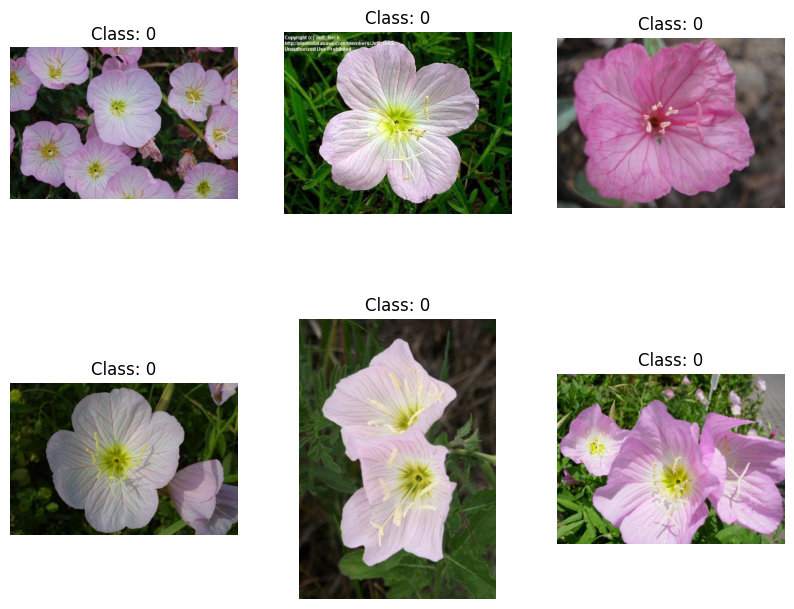

In [21]:
import matplotlib.pyplot as plt
import torchvision

# Load WITHOUT transforms
raw_dataset = torchvision.datasets.Flowers102(
    root="./data",
    split="train",
    download=True
)

plt.figure(figsize=(10, 8))

for i in range(6):
    img, label = raw_dataset[i]
    
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(f"Class: {label}")
    plt.axis("off")

plt.show()

In [12]:
from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

 Load pretrained model

In [13]:
model = torchvision.models.convnext_base(weights=weights)
model = model.to(device)

ConvNeXt is trained for 1000 classes (ImageNet)
But Flowers102 has 102 classes

In [14]:
import torch.nn as nn

model.classifier[2] = nn.Linear(model.classifier[2].in_features, 102)

In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [16]:
#Training Loop
for epoch in range(3):
    model.train()
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

Epoch 1, Loss: 4.120583534240723
Epoch 2, Loss: 2.738692045211792
Epoch 3, Loss: 1.61224365234375


In [27]:
from functools import partial
import torchvision
from torch.utils.data import DataLoader

weights = torchvision.models.ConvNeXt_Base_Weights.DEFAULT
DefaultFlowers102 = partial(
    torchvision.datasets.Flowers102,
    root="datasets",
    transform=weights.transforms(),
    download=True
)
train_set = DefaultFlowers102(split="train")
valid_set = DefaultFlowers102(split="val")
test_set  = DefaultFlowers102(split="test")
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)

100.0%
100.0%
100.0%


In [28]:
class_names = ['pink primrose', 'hard-leaved pocket orchid', 'canterbury bells', 'sweet pea', 'english marigold', 'tiger lily', 'moon orchid', 'bird of paradise', 'monkshood', 'globe thistle', 'snapdragon', "colt's foot", 'king protea', 'spear thistle', 'yellow iris', 'globe-flower', 'purple coneflower', 'peruvian lily', 'balloon flower', 'giant white arum lily', 'fire lily', 'pincushion flower', 'fritillary', 'red ginger', 'grape hyacinth', 'corn poppy', 'prince of wales feathers', 'stemless gentian', 'artichoke', 'sweet william', 'carnation', 'garden phlox', 'love in the mist', 'mexican aster', 'alpine sea holly', 'ruby-lipped cattleya', 'cape flower', 'great masterwort', 'siam tulip', 'lenten rose', 'barbeton daisy', 'daffodil', 'sword lily', 'poinsettia', 'bolero deep blue', 'wallflower', 'marigold', 'buttercup', 'oxeye daisy', 'common dandelion', 'petunia', 'wild pansy', 'primula', 'sunflower', 'pelargonium', 'bishop of llandaff', 'gaura', 'geranium', 'orange dahlia', 'pink-yellow dahlia?', 'cautleya spicata', 'japanese anemone', 'black-eyed susan', 'silverbush', 'californian poppy', 'osteospermum', 'spring crocus', 'bearded iris', 'windflower', 'tree poppy', 'gazania', 'azalea', 'water lily', 'rose', 'thorn apple', 'morning glory', 'passion flower', 'lotus', 'toad lily', 'anthurium', 'frangipani', 'clematis', 'hibiscus', 'columbine', 'desert-rose', 'tree mallow', 'magnolia', 'cyclamen', 'watercress', 'canna lily', 'hippeastrum', 'bee balm', 'ball moss', 'foxglove', 'bougainvillea', 'camellia', 'mallow', 'mexican petunia', 'bromelia', 'blanket flower', 'trumpet creeper', 'blackberry lily']

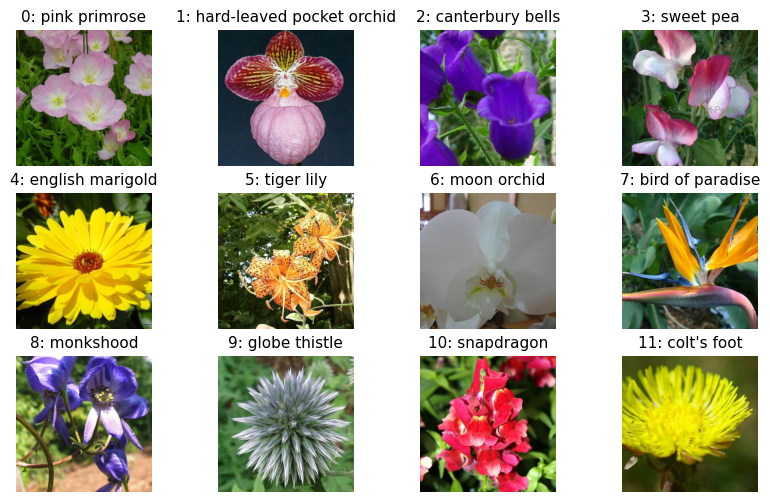

In [30]:
# extra code – displays the 1st image of classes 0 to 11 in the train set
import matplotlib.pyplot as plt

def plot_image(img):
    if img.shape[0] == 3:  # (C, H, W)
        img = img.permute(1, 2, 0)  # → (H, W, C)
    plt.imshow(img)
    plt.axis("off")
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.CenterCrop(500),
])
flowers_to_display = DefaultFlowers102(split="train", transform=transform)
sample_flowers = sorted({y: img for img, y in flowers_to_display}.items())[:12]

plt.figure(figsize=(10, 6))
for class_id, image in sample_flowers:
    if class_id == 12: break
    plt.subplot(3, 4, class_id + 1)
    plot_image(image)
    plt.title(f"{class_id}: {class_names[class_id]}", fontsize=11)

plt.show()

In [31]:
[name for name, child in model.named_children()]

['features', 'avgpool', 'classifier']

In [32]:
model.classifier

Sequential(
  (0): LayerNorm2d((1024,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=1024, out_features=102, bias=True)
)

In [33]:
n_classes = 102  # len(class_names) == 102
model.classifier[2] = nn.Linear(1024, n_classes).to(device)


In [34]:
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

In [39]:
def train(model, optimizer, loss_fn, metric,
          train_loader, valid_loader, n_epochs):

    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(n_epochs):
        # Training
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = loss_fn(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)

        # Validation
        model.eval()
        val_loss = 0
        metric.reset()

        with torch.no_grad():
            for images, labels in valid_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = loss_fn(outputs, labels)

                val_loss += loss.item()
                metric.update(outputs, labels)

        avg_val_loss = val_loss / len(valid_loader)
        val_acc = metric.compute().item()

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{n_epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | "
              f"Val Acc: {val_acc:.4f}")

    return history

In [41]:
from torch.utils.data import DataLoader

valid_loader = DataLoader(valid_set, batch_size=32)

In [42]:
history = train(model, optimizer, xentropy, accuracy,
                train_loader, valid_loader, n_epochs)

Epoch 1/3 | Train Loss: 3.2952 | Val Loss: 1.7734 | Val Acc: 0.8735
Epoch 2/3 | Train Loss: 0.9851 | Val Loss: 0.7115 | Val Acc: 0.9255
Epoch 3/3 | Train Loss: 0.3267 | Val Loss: 0.4519 | Val Acc: 0.9451
